# Free-throw distributions: the ten highest-volume players of 2025-26

The [Shai free throws notebook](shai_free_throws.ipynb) found that SGA's free-throw counts are
**negative binomial** — beating a discretized lognormal and a Poisson on AIC in every season —
and argued the reason is structural rather than empirical: makes are a *binomial thinning* of
attempts, and the negative binomial is closed under thinning.

Both of those claims were tested on one player. This notebook re-runs them across the ten
players who got to the line most in 2025-26, which turns an anecdote into ten independent
checks:

1. Does the negative binomial keep winning, for **FTA and FTM**, for every player?
2. Does the thinning prediction — r preserved between attempts and makes — hold up ten times?

Season convention: the ending year — `2026` = the 2025-26 season, the most recent completed one.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nba_analysis import compare_models, fit_nbinom, get_game_logs, get_league_leaders, thinning_check

sns.set_theme(style="whitegrid")

SEASON = 2026

# Categorical slots 1 and 2 from the reference palette (light surface).
STAT_COLORS = {"FTA": "#2a78d6", "FTM": "#008300"}
LABEL_INK = "#52514e"

## The ten players

NBA.com applies its own qualification rule to the leaderboard (a games-played minimum), so
these are all full-season players rather than small-sample outliers — the lowest games played
below is 61.

In [2]:
leaders = get_league_leaders(SEASON, stat="FTA").nlargest(10, "FTA")
top10 = leaders[["PLAYER", "PLAYER_ID", "TEAM", "GP", "MIN", "FTA", "FTM", "FT_PCT", "PTS"]].reset_index(drop=True)
top10.index += 1
top10

,PLAYER,PLAYER_ID,TEAM,GP,MIN,FTA,FTM,FT_PCT,PTS
1,Luka Dončić,1629029,LAL,64,35.8,10.1,7.9,0.780,33.5
2,Deni Avdija,1630166,POR,66,33.3,9.2,7.4,0.802,24.2
3,Shai Gilgeous-Alexander,1628983,OKC,68,33.2,9.0,7.9,0.879,31.1
4,Paolo Banchero,1631094,ORL,72,34.8,8.2,6.3,0.775,22.2
5,Devin Booker,1626164,PHX,64,33.5,8.1,7.1,0.873,26.1
6,Jaylen Brown,1627759,BOS,71,34.4,7.5,6.0,0.795,28.7
7,Zion Williamson,1629627,NOP,62,29.7,7.5,5.4,0.716,21.0
8,James Harden,201935,CLE,70,34.8,7.5,6.6,0.884,23.6
9,Nikola Jokić,203999,DEN,65,34.8,7.4,6.1,0.831,27.7
10,Anthony Edwards,1630162,MIN,61,35.0,7.2,5.7,0.796,28.8


In [3]:
# One cached fetch per player; game logs are keyed by PLAYER_ID rather than name so
# that diacritics ("Dončić", "Jokić") can't turn into a lookup problem.
logs = {row.PLAYER: get_game_logs(int(row.PLAYER_ID), SEASON) for row in top10.itertuples()}

# Guard against the upstream game-log corruption documented in nba_analysis.data:
# every player's row count must match the leaderboard's games played.
mismatch = {p: (len(df), int(top10.loc[top10.PLAYER == p, "GP"].iloc[0]))
            for p, df in logs.items()
            if len(df) != int(top10.loc[top10.PLAYER == p, "GP"].iloc[0])}
assert not mismatch, f"game log / GP mismatch: {mismatch}"

print(f"{len(logs)} players, {sum(len(d) for d in logs.values())} games, all row counts match GP")

10 players, 663 games, all row counts match GP


## Individual graphs per player

One panel per player, attempts and makes together. Points are the observed share of games at
each integer — the only place the data actually lives. The line is the **fitted negative
binomial**, drawn continuously only so it reads as a model rather than as data; like the
points, it's really only defined on the integers.

The panels share an x axis so the players can be read against each other.

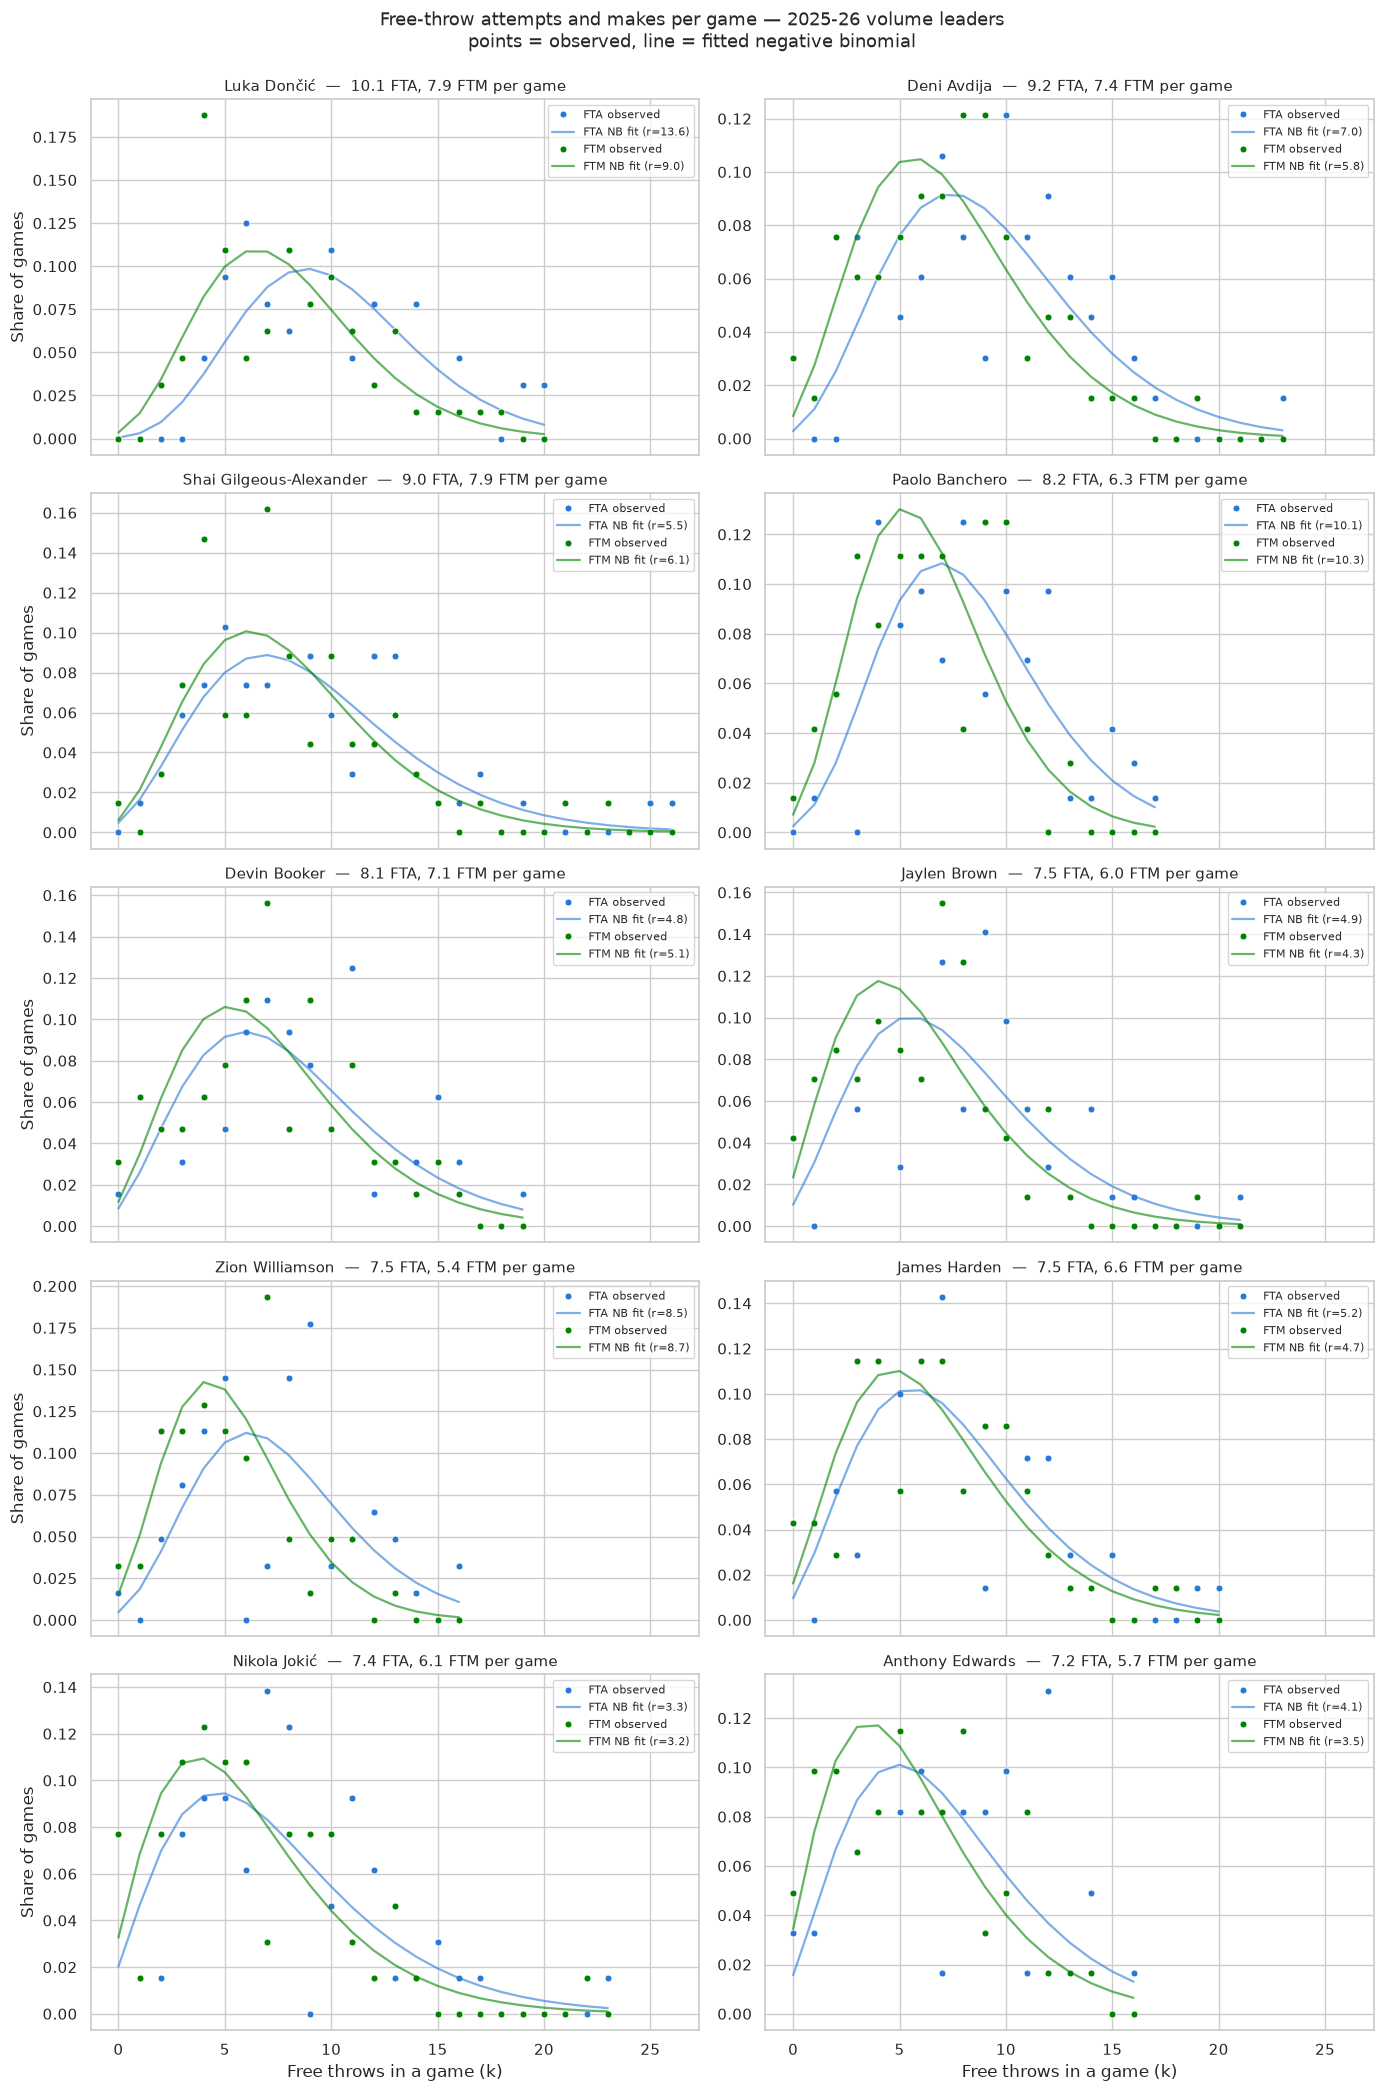

In [4]:
def ft_panel(ax, player, df):
    """Draw observed FTA/FTM mass plus fitted NB curves for one player."""
    kmax = int(max(df.FTA.max(), df.FTM.max()))
    ks = np.arange(0, kmax + 1)

    for stat, color in STAT_COLORS.items():
        values = df[stat].to_numpy()
        observed = np.array([(values == k).mean() for k in ks])
        fit = fit_nbinom(values)

        ax.plot(ks, observed, marker="o", markersize=5, linewidth=0, color=color,
                markeredgecolor="white", markeredgewidth=0.6, label=f"{stat} observed")
        ax.plot(ks, fit.pmf(ks), linewidth=1.6, color=color, alpha=0.6,
                label=f"{stat} NB fit (r={fit.r:.1f})")

    ax.set_title(f"{player}  —  {df.FTA.mean():.1f} FTA, {df.FTM.mean():.1f} FTM per game",
                 fontsize=11)
    ax.legend(loc="upper right", fontsize=8, frameon=True)


fig, axes = plt.subplots(5, 2, figsize=(14, 21), sharex=True)
for ax, (player, df) in zip(axes.ravel(), logs.items()):
    ft_panel(ax, player, df)
for ax in axes[:, 0]:
    ax.set_ylabel("Share of games")
# Only the bottom row carries tick labels under sharex, so only it gets an axis label.
for ax in axes[-1, :]:
    ax.set_xlabel("Free throws in a game (k)")

fig.suptitle("Free-throw attempts and makes per game — 2025-26 volume leaders\n"
             "points = observed, line = fitted negative binomial", y=0.995, fontsize=13)
plt.tight_layout()
plt.show()

Every panel shows the same picture: a single-peaked, mildly right-skewed count with the NB
curve running through the observed points. Attempts (blue) sit to the right of makes (green)
by the size of each player's miss rate — widest for Zion Williamson, whose FT% is the worst of
the group, and nearly touching for the best shooters.

## Does the negative binomial keep winning?

Same three candidates as the SGA notebook, all scored on the same discrete support, with the
lognormal discretized (P(X=k) = F(k+½) − F(k−½)) so its likelihood is comparable and so it can
tolerate the zeros that real game logs contain.

`ΔAIC vs next` is the winner's margin over the runner-up, which matters as much as the win
itself: a margin under ~2 means the two models are effectively indistinguishable on this data,
so read those rows as ties rather than verdicts.

In [5]:
rows = []
for player, df in logs.items():
    for stat in STAT_COLORS:
        x = df[stat].to_numpy()
        aics = compare_models(x)
        ranked = sorted(aics.values())
        rows.append({
            "PLAYER": player,
            "STAT": stat,
            "n": len(x),
            "var/mean": x.var(ddof=1) / x.mean(),
            **aics,
            "best": min(aics, key=aics.get),
            "ΔAIC vs next": ranked[1] - ranked[0],
        })

model_fits = pd.DataFrame(rows).set_index(["PLAYER", "STAT"])
model_fits.round(1)

n  var/mean  NegBinom  discLogNorm  Poisson  \
PLAYER                  STAT                                                 
Luka Dončić             FTA   64       1.8     363.7        362.2    373.7   
                        FTM   64       1.9     350.4        350.1    363.9   
Deni Avdija             FTA   66       2.1     390.3        423.7    414.5   
                        FTM   66       2.1     371.4        398.2    394.2   
Shai Gilgeous-Alexander FTA   68       2.8     402.4        405.9    446.1   
                        FTM   68       2.4     385.4        397.6    415.1   
Paolo Banchero          FTA   72       1.8     397.5        408.0    409.7   
                        FTM   72       1.5     372.6        395.1    378.7   
Devin Booker            FTA   64       2.4     375.1        398.1    408.5   
                        FTM   64       2.1     359.9        387.2    383.8   
Jaylen Brown            FTA   71       2.3     406.8        438.7    439.4   
                        FTM   71       2.2     383.4        408.9    411.6   
Zion Williamson         FTA   62       1.8     339.7        357.3    351.2   
                        FTM   62       1.6     309.2        329.4    314.6   
James Harden            FTA   70       2.3     397.8        428.6    428.9   
                        FTM   70       2.2     386.9        415.1    415.8   
Nikola Jokić            FTA   65       2.8     381.7        416.8    432.4   
                        FTM   65       2.8     361.4        388.5    405.8   
Anthony Edwards         FTA   61       2.4     348.8        370.2    381.1   
                        FTM   61       2.3     329.9        350.0    359.3   

                                     best  ΔAIC vs next  
PLAYER                  STAT                             
Luka Dončić             FTA   discLogNorm           1.5  
                        FTM   discLogNorm           0.4  
Deni Avdija             FTA      NegBinom          24.1  
                        FTM      NegBinom          22.7  
Shai Gilgeous-Alexander FTA      NegBinom           3.5  
                        FTM      NegBinom          12.2  
Paolo Banchero          FTA      NegBinom          10.5  
                        FTM      NegBinom           6.1  
Devin Booker            FTA      NegBinom          23.0  
                        FTM      NegBinom          23.9  
Jaylen Brown            FTA      NegBinom          31.9  
                        FTM      NegBinom          25.5  
Zion Williamson         FTA      NegBinom          11.6  
                        FTM      NegBinom           5.5  
James Harden            FTA      NegBinom          30.9  
                        FTM      NegBinom          28.2  
Nikola Jokić            FTA      NegBinom          35.1  
                        FTM      NegBinom          27.1  
Anthony Edwards         FTA      NegBinom          21.5  
                        FTM      NegBinom          20.1

In [6]:
print(model_fits.best.value_counts().to_string())
print()
print(f"NB wins {(model_fits.best == 'NegBinom').sum()} of {len(model_fits)} player-stat combinations")
print(f"Median ΔAIC over the next-best model: {model_fits['ΔAIC vs next'].median():.1f}")
print(f"var/mean range: {model_fits['var/mean'].min():.2f} to {model_fits['var/mean'].max():.2f} "
      f"(Poisson requires exactly 1.0)")

best
NegBinom       18
discLogNorm     2

NB wins 18 of 20 player-stat combinations
Median ΔAIC over the next-best model: 22.1
var/mean range: 1.53 to 2.83 (Poisson requires exactly 1.0)


## The thinning prediction, ten times over

The structural claim: makes are attempts thinned by a per-shot make probability, and the
negative binomial is closed under binomial thinning with **r preserved**. So fitting FTA and
FTM independently should recover roughly the same r for each player.

This is the real test. On one player, r = 7.33 against 7.90 is a coincidence away from
meaningless; across ten players it either holds or it doesn't. The diagonal is equality — the
prediction is that points land on it, with scatter from two noisy MLEs on ~65 games each.

In [7]:
thinning = pd.DataFrame(
    [{"PLAYER": player, **thinning_check(df.FTA.to_numpy(), df.FTM.to_numpy())}
     for player, df in logs.items()]
).set_index("PLAYER")

thinning.round(2)

,r_attempts,r_makes,ratio,p_attempts,p_makes
PLAYER,,,,,
Luka Dončić,13.57,9.03,0.67,0.57,0.53
Deni Avdija,6.96,5.81,0.83,0.43,0.44
Shai Gilgeous-Alexander,5.49,6.12,1.11,0.38,0.44
Paolo Banchero,10.10,10.30,1.02,0.55,0.62
Devin Booker,4.81,5.08,1.06,0.37,0.42
Jaylen Brown,4.92,4.30,0.87,0.39,0.42
Zion Williamson,8.49,8.66,1.02,0.53,0.62
James Harden,5.22,4.69,0.90,0.41,0.41
Nikola Jokić,3.35,3.19,0.95,0.31,0.34


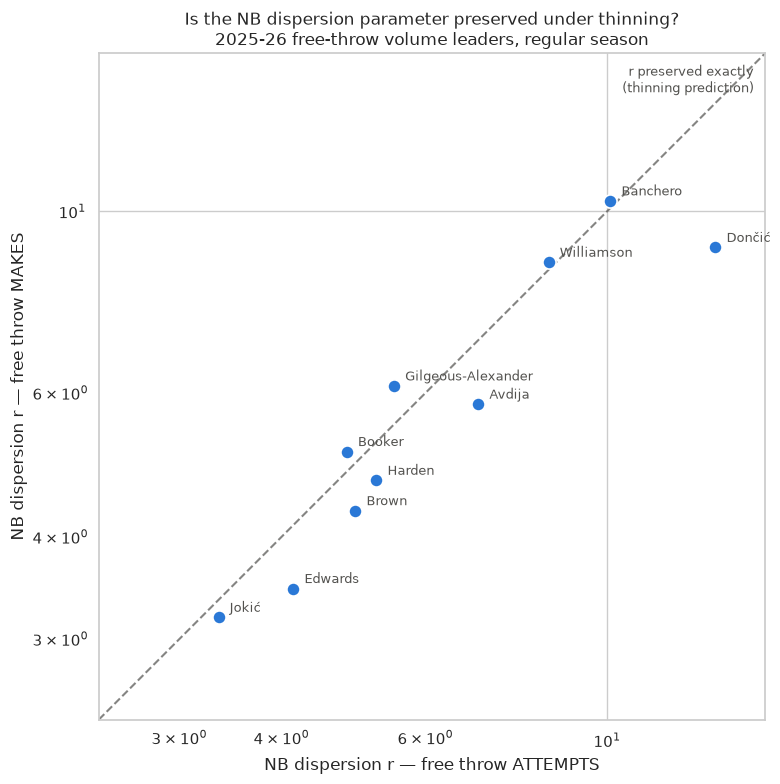

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

lo = min(thinning.r_attempts.min(), thinning.r_makes.min()) * 0.75
hi = max(thinning.r_attempts.max(), thinning.r_makes.max()) * 1.15

ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1.5, color=LABEL_INK, alpha=0.7, zorder=1)
ax.annotate("r preserved exactly\n(thinning prediction)", (hi, hi), xytext=(-8, -28),
            textcoords="offset points", ha="right", color=LABEL_INK, fontsize=9)

ax.scatter(thinning.r_attempts, thinning.r_makes, s=90, color=STAT_COLORS["FTA"],
           edgecolor="white", linewidth=1.2, zorder=3)

for player, row in thinning.iterrows():
    ax.annotate(player.split()[-1], (row.r_attempts, row.r_makes), xytext=(8, 4),
                textcoords="offset points", color=LABEL_INK, fontsize=9)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
ax.set_xlabel("NB dispersion r — free throw ATTEMPTS")
ax.set_ylabel("NB dispersion r — free throw MAKES")
ax.set_title("Is the NB dispersion parameter preserved under thinning?\n"
             "2025-26 free-throw volume leaders, regular season")
plt.tight_layout()
plt.show()

In [9]:
ratios = thinning.ratio
print(f"r_makes / r_attempts across the ten players:")
print(f"  median {ratios.median():.2f}   mean {ratios.mean():.2f}   range {ratios.min():.2f} to {ratios.max():.2f}")
print(f"  within +/-25% of 1.0: {((ratios > 0.75) & (ratios < 1.25)).sum()} of {len(ratios)}")

r_makes / r_attempts across the ten players:
  median 0.92   mean 0.93   range 0.67 to 1.11
  within +/-25% of 1.0: 9 of 10


## Summary

**The negative binomial finding mostly generalizes: 18 of 20.** Ten players × (attempts, makes),
and NB takes all but two. Both exceptions are Dončić, whose attempts and makes are nominally
won by the discretized lognormal — but by 1.5 and 0.3 AIC, comfortably inside the conventional
ΔAIC ≈ 2 band where two models are considered indistinguishable. Those are honest ties, not
losses, and where NB does win it tends to win decisively: the median margin over the next-best
model is 22.1 AIC. Poisson never wins, for a legible reason: `var/mean` runs from about 1.5 to
2.8 across the group, where Poisson requires exactly 1.0. That overdispersion is what the NB's
second parameter exists to absorb.

It's worth noting *which* player produced the ties. Dončić has by far the highest fitted
dispersion (r ≈ 13.6 for attempts, against 3.3 for Jokić), which puts him closest to the
Poisson end of the NB family and makes his distribution the least distinctive — the easiest
one for another two-parameter model to match.

**The thinning prediction holds, loosely.** The r values cluster along the diagonal rather than
scattering: the median r_makes/r_attempts ratio is 0.92, and nine of ten players land within
±25% of equality. That's the qualitative signature the theory predicts.

It is not precise agreement, and it shouldn't be read as one. Each r is a noisy MLE from ~65
games, and r is the hardest NB parameter to pin down — the likelihood is notoriously flat in
it. That flatness explains the one real outlier: Dončić (ratio 0.67) has the highest r in the
group, and at large r the NB approaches Poisson, where r is barely identified at all. The
claim this supports is "dispersion survives thinning roughly intact", not
"r_makes = r_attempts".

**What this does not establish.** AIC ranks these three candidates against each other; it says
nothing about whether the winner is *correct*. A real goodness-of-fit test would need a
parametric bootstrap — the ties and the estimated parameters both make a naive KS test invalid
here. And these are ten high-volume players selected *because* they attempt many free throws;
whether the result extends to low-volume players, whose counts are squashed toward zero and
likely need a hurdle or zero-inflated model, is a different question this notebook doesn't
answer.